9.- Entrena un LinearSVC en un conjunto de datos separables linealmente. Después entrena un SVC y un SGDClassifier en el mismo conjunto de datos. Mira si puedes conseguir que produzcan aproximadamente el mismo modelo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

# Conjunto de datos linealmente separable
X, y = make_blobs(
    n_samples=200,
    centers=[(-2, -2), (2, 2)],
    cluster_std=0.7,
    random_state=42,
)

# El escalado favorece la convergencia de las SVM y SGD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C = 1.0

linear_svc = LinearSVC(
    C=C,
    loss="hinge",
    dual=True,
    max_iter=100_000,
    random_state=42,
)

svc = SVC(
    C=C,
    kernel="linear",
)

# Relación aproximada entre la regularización de SVM y SGD
sgd_clf = SGDClassifier(
    loss="hinge",
    alpha=1 / (C * len(X_scaled)),
    max_iter=100_000,
    tol=1e-7,
    random_state=42,
)

models = {
    "LinearSVC": linear_svc,
    "SVC lineal": svc,
    "SGDClassifier": sgd_clf,
}

for name, model in models.items():
    model.fit(X_scaled, y)

    print(f"\n{name}")
    print("Exactitud:", accuracy_score(y, model.predict(X_scaled)))
    print("Coeficientes:", model.coef_)
    print("Intercepto:", model.intercept_)


LinearSVC
Exactitud: 1.0
Coeficientes: [[1.00310431 1.12110753]]
Intercepto: [0.02601735]

SVC lineal
Exactitud: 1.0
Coeficientes: [[1.00486413 1.11868266]]
Intercepto: [0.02636416]

SGDClassifier
Exactitud: 1.0
Coeficientes: [[1.07075429 1.21162065]]
Intercepto: [0.0424967]


In [ ]:
predictions = {
    name : model.predict(X_scaled)
    for name, model in models.items()
}

names = list(models)

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        agreement = np.mean(
            predictions[names[i]] == predictions[names[j]]
        )
        print(f"{names[i]} vs. {names[j]}: {agreement:.2%}")

LinearSVC vs. SVC lineal: 100.00%
LinearSVC vs. SGDClassifier: 100.00%
SVC lineal vs. SGDClassifier: 100.00%


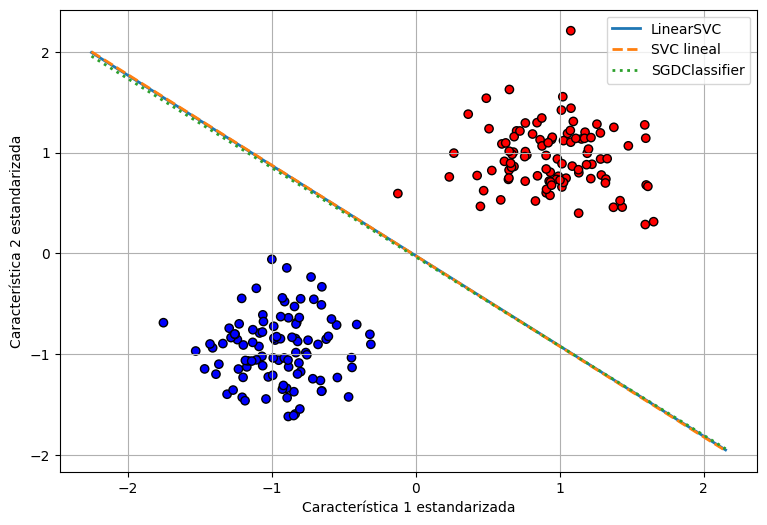

In [3]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    cmap="bwr",
    edgecolors="k",
)

x0 = np.linspace(
    X_scaled[:, 0].min() - 0.5,
    X_scaled[:, 0].max() + 0.5,
    200,
)

styles = ["-", "--", ":"]

for (name, model), style in zip(models.items(), styles):
    w = model.coef_[0]
    b = model.intercept_[0]
    x1 = -(w[0] * x0 + b) / w[1]
    plt.plot(x0, x1, style, linewidth=2, label=name)

plt.xlabel("Característica 1 estandarizada")
plt.ylabel("Característica 2 estandarizada")
plt.legend()
plt.grid()
plt.show()

10.- Entrena un classificador SVM en ele conjunto de datos wine, que puedes caragar utilizando sklearn.datasets.load_wine(). Este conjunto de datos contiene los análisis químicos de 178 muestras de vino producidas por 3 agricultores diferentes: el objetivo es entrenar un modelo de clasificacion capaz de predecir el agricultor basándose en el análisis químico del vino. Puesto que los classificadores SVM són binarios, tendrás que que utilizar one-versus-all para clasificar las tres clases. ¿ Qué exactitud puedes lograr ?

### Solución

Se reserva un conjunto de prueba estratificado y se aplica el escalado sin
filtrar información. Como `SVC` es binario, se envuelve explícitamente en
`OneVsRestClassifier` para entrenar un clasificador por cada tipo de vino.

In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    random_state=42,
    stratify=y_wine,
)

print(f"Entrenamiento: {X_train_wine.shape}")
print(f"Prueba: {X_test_wine.shape}")
print(f"Clases: {list(wine.target_names)}")

Entrenamiento: (133, 13)
Prueba: (45, 13)
Clases: ['class_0', 'class_1', 'class_2']


In [5]:
wine_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("ovr", OneVsRestClassifier(SVC())),
])

param_grid = [
    {
        "ovr__estimator__kernel": ["linear"],
        "ovr__estimator__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "ovr__estimator__kernel": ["rbf"],
        "ovr__estimator__C": [0.1, 1, 10, 100],
        "ovr__estimator__gamma": ["scale", 0.01, 0.1, 1],
    },
]

wine_search = GridSearchCV(
    wine_svm,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
wine_search.fit(X_train_wine, y_train_wine)

print("Mejores hiperparámetros:", wine_search.best_params_)
print(f"Exactitud media de validación: {wine_search.best_score_:.2%}")

Mejores hiperparámetros: {'ovr__estimator__C': 1, 'ovr__estimator__kernel': 'linear'}
Exactitud media de validación: 99.26%


Exactitud en prueba: 97.78% (44/45)

Informe de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



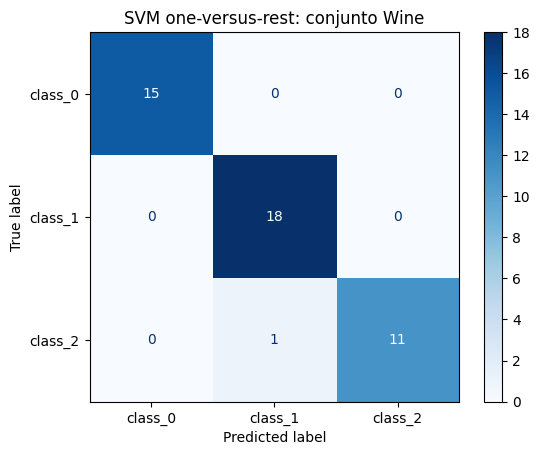

In [ ]:
y_pred_wine = wine_search.predict(X_test_wine)
wine_accuracy = accuracy_score(y_test_wine, º)

print(
    f"Exactitud en prueba: {wine_accuracy:.2%} "
    f"({(y_pred_wine == y_test_wine).sum()}/{len(y_test_wine)})"
)
print("\nInforme de clasificación:")
print(
    classification_report(
        y_test_wine,
        y_pred_wine,
        target_names=wine.target_names,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test_wine,
    y_pred_wine,
    display_labels=wine.target_names,
    cmap="Blues",
)
plt.title("SVM one-versus-rest: conjunto Wine")
plt.show()

**Conclusión:** el mejor modelo consigue aproximadamente un
**97,8 % de exactitud** en el conjunto de prueba (44 predicciones correctas
de 45). La matriz de confusión permite ver que solo se confunde una muestra.

11 .- Entrena y perfecciona un regresor SVM en el conjunto de datos de las casas de California. Puedes utiltizar el conjunto de datos original, en vez de la versión modificada que hemos utilizado en el capitulo 2, que puedes cargar utilizando sklearn.datasets.fetch_california_housing(). Los objetivos representan cinetos de miles de dólares. Puesto que hay mas de 20.000 instancias, las SVM pueden ser lentas, así que, para el ajuste de hiperparámetros, deberías utilizar muchas menos instancias ( por ejemplo, 2.000) para probar muchas mas combinaciones de hiperparámetros. ¿ Cuál es la RECM de tu mejor modelo ?

### Solución

El conjunto se divide antes de ajustar ningún componente. La búsqueda de
hiperparámetros se realiza con solo 2.000 instancias del conjunto de
entrenamiento. Una vez elegida la mejor configuración, se vuelve a entrenar
el modelo con todas las instancias de entrenamiento y se evalúa una sola vez
en el conjunto de prueba.

In [7]:
import matplotlib.pyplot as plt

from scipy.stats import loguniform
from sklearn.base import clone
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

X_train_housing, X_test_housing, y_train_housing, y_test_housing = (
    train_test_split(
        X_housing,
        y_housing,
        test_size=0.20,
        random_state=42,
    )
)

# Muestra utilizada únicamente para buscar los hiperparámetros.
X_tune, _, y_tune, _ = train_test_split(
    X_train_housing,
    y_train_housing,
    train_size=2_000,
    random_state=42,
)

print(f"Conjunto completo: {X_housing.shape}")
print(f"Entrenamiento: {X_train_housing.shape}")
print(f"Prueba: {X_test_housing.shape}")
print(f"Muestra para el ajuste: {X_tune.shape}")

Conjunto completo: (20640, 8)
Entrenamiento: (16512, 8)
Prueba: (4128, 8)
Muestra para el ajuste: (2000, 8)


In [8]:
housing_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf")),
])

param_distributions = {
    "svr__C": loguniform(1, 100),
    "svr__gamma": loguniform(0.01, 0.3),
    "svr__epsilon": loguniform(0.03, 0.3),
}

housing_search = RandomizedSearchCV(
    housing_svr,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)
housing_search.fit(X_tune, y_tune)

print("Mejores hiperparámetros:")
print(housing_search.best_params_)
print(
    "RECM media de validación: "
    f"{-housing_search.best_score_:.4f}"
)

Mejores hiperparámetros:
{'svr__C': 5.211124595788264, 'svr__epsilon': 0.03917331404699168, 'svr__gamma': 0.18832519048593593}
RECM media de validación: 0.5581


In [9]:
# RandomizedSearchCV solo reajustó el modelo sobre las 2.000 muestras.
# Ahora entrenamos la mejor configuración con todo el conjunto de entrenamiento.
best_housing_svr = clone(housing_search.best_estimator_)
best_housing_svr.fit(X_train_housing, y_train_housing)

y_pred_housing = best_housing_svr.predict(X_test_housing)

housing_rmse = root_mean_squared_error(y_test_housing, y_pred_housing)
housing_mae = mean_absolute_error(y_test_housing, y_pred_housing)
housing_r2 = r2_score(y_test_housing, y_pred_housing)

print(f"RECM en prueba: {housing_rmse:.4f}")
print(f"Error absoluto medio: {housing_mae:.4f}")
print(f"R²: {housing_r2:.4f}")
print(f"RECM aproximada en dólares: ${housing_rmse * 100_000:,.0f}")

RECM en prueba: 0.5655
Error absoluto medio: 0.3731
R²: 0.7560
RECM aproximada en dólares: $56,547


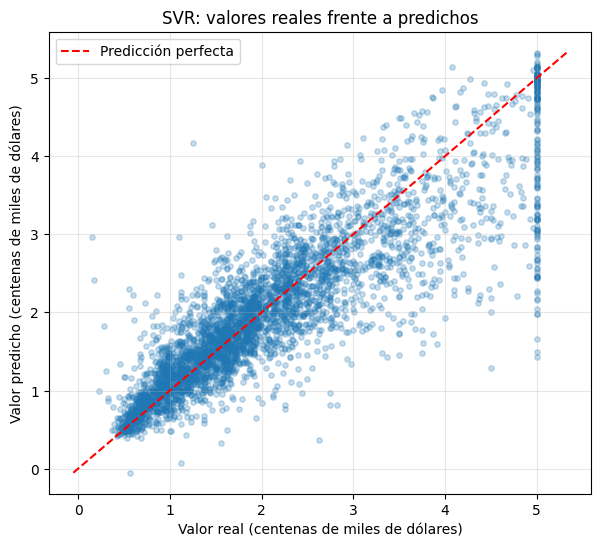

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(
    y_test_housing,
    y_pred_housing,
    alpha=0.25,
    s=15,
)
limits = [
    min(y_test_housing.min(), y_pred_housing.min()),
    max(y_test_housing.max(), y_pred_housing.max()),
]
plt.plot(limits, limits, "r--", label="Predicción perfecta")
plt.xlabel("Valor real (centenas de miles de dólares)")
plt.ylabel("Valor predicho (centenas de miles de dólares)")
plt.title("SVR: valores reales frente a predichos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Conclusión:** el SVR ajustado obtiene una RECM aproximada de
**0,565**, es decir, unos **56.500 USD**. La RECM se calcula exclusivamente
sobre el conjunto de prueba, que no se utilizó durante el ajuste de
hiperparámetros.